# Task 5 — End-to-End Seq2Seq Machine Translation Implementation

In this notebook, we implement the complete Sequence-to-Sequence (Seq2Seq) Encoder-Decoder architecture in PyTorch from scratch. 

To make this task realistic, we will download and use a subset of a real translation corpus — the **NLTK ComTrans English-French Parallel Corpus** — containing real-world political sentences.

We will configure the model to translate **English to French**, allowing you to enter an English sentence and receive its French translation.

We will use this real dataset to practically evaluate all the concepts discussed in this phase:
1. **Teacher Forcing** vs. **Free-Running** training.
2. **Greedy Decoding** vs. **Beam Search Decoding** (demonstrating real search space victories).
3. **The Information Bottleneck** (analyzing model accuracy against sentence length).
4. **Interactive GUI**: A real-time translation playground.

---

## 💡 Key Findings

*   **Teacher Forcing Accelerated Convergence**: Training with 100% Teacher Forcing reached low loss values rapidly. Free-running training (ratio=0.0) fluctuated significantly early on due to error cascading.
*   **Beam Search Resolved Local Traps**: On unseen test sentences, Greedy Decoding made locally optimal selections early on that led to generic phrases like `"we owe this to our citizens"`. Beam Search ($k=3$) evaluated cumulative path probabilities and retrieved higher probability translations.
*   **Length Bottleneck Confirmed**: Model accuracy decreased monotonically as sentence length increased, demonstrating the empirical constraint of the fixed-size context vector.


### Step 1 — Load and Clean NLTK ComTrans Parallel Corpus

We load 500 parallel English-French sentence pairs from the ComTrans corpus. We clean basic formatting and limit sentence lengths to make the model run quickly on standard CPU setups.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random
import re
import numpy as np
import matplotlib.pyplot as plt
import nltk

# Downloader helper for NLTK corpora
try:
    from nltk.corpus import comtrans
except LookupError:
    nltk.download('comtrans')
    from nltk.corpus import comtrans

# 1. Parse the parallel corpus raw data
raw_lines = comtrans.raw('alignment-en-fr.txt').split('\n')
pairs = []
seen = set()

# The corpus raw lines are organized in 3-line blocks: English, French, and Alignment mapping indices
for i in range(0, len(raw_lines) - 2, 3):
    eng = raw_lines[i].strip()
    fre = raw_lines[i+1].strip()
    if not eng or not fre:
        continue
    
    # 2. Clean sentences: remove non-alphabetic chars and lowercase
    eng_clean = re.sub(r'[^a-zA-Z\s]', '', eng).lower().strip()
    fre_clean = re.sub(r'[^a-zA-Z\s]', '', fre).lower().strip()
    
    # Normalize extra whitespaces
    eng_clean = re.sub(r'\s+', ' ', eng_clean)
    fre_clean = re.sub(r'\s+', ' ', fre_clean)
    
    if not eng_clean or not fre_clean:
        continue
        
    eng_words = eng_clean.split()
    fre_words = fre_clean.split()
    
    # 3. Filter for sentences of length 3 to 6 words to optimize training on CPU
    if 3 <= len(eng_words) <= 6 and 3 <= len(fre_words) <= 6:
        # Avoid parliamentary labels and meta-headings
        if any(w in fre_clean for w in ['rapport', 'mercredi', 'session', 'commission', 'parlement']):
            continue
        pair_str = f"{eng_clean} | {fre_clean}"
        if pair_str not in seen:
            seen.add(pair_str)
            # Source: English (index 0), Target: French (index 1)
            pairs.append((eng_clean, fre_clean))

# Sort and shuffle deterministically for reproducibility
pairs = sorted(pairs, key=lambda x: x[0])
random.seed(42)
random.shuffle(pairs)

# 4. Extract train (500 pairs) and test (10 pairs) sets
train_pairs = pairs[:500]
test_pairs = pairs[500:510]

# Vocab builder
def build_vocab(sentences):
    words = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
    for s in sentences:
        words.extend(s.lower().split())
    unique = sorted(list(set(words)))
    w2idx = {w: i for i, w in enumerate(unique)}
    idx2w = {i: w for w, i in w2idx.items()}
    return w2idx, idx2w

src_w2idx, src_idx2w = build_vocab([p[0] for p in train_pairs])
tgt_w2idx, tgt_idx2w = build_vocab([p[1] for p in train_pairs])

MAX_LEN = 10

# Helper to format string into vocab indexes
def sentence_to_indices(sentence, w2idx):
    indices = [w2idx.get(w, w2idx["<UNK>"]) for w in sentence.lower().split()]
    indices.append(w2idx["<EOS>"])
    if len(indices) < MAX_LEN:
        indices += [w2idx["<PAD>"]] * (MAX_LEN - len(indices))
    return indices[:MAX_LEN]

# Convert clean dataset lists into index representation lists
pairs_idx = [(sentence_to_indices(eng, src_w2idx), sentence_to_indices(fre, tgt_w2idx)) for eng, fre in train_pairs]

print(f"Source (English) Vocab Size: {len(src_w2idx)}")
print(f"Target (French) Vocab Size: {len(tgt_w2idx)}")
print(f"Total training pairs: {len(train_pairs)}")
print(f"Total testing pairs: {len(test_pairs)}")


Source (English) Vocab Size: 804
Target (French) Vocab Size: 908
Total training pairs: 500
Total testing pairs: 10


### Step 2 — Define Encoder and Decoder Modules

We build a GRU-based Seq2Seq architecture in PyTorch from scratch.

*   **Encoder**: Maps input indices to embeddings, then processes them sequentially with a GRU. The final hidden state acts as the Context Vector.
*   **Decoder**: Takes a single token index and the hidden state, embeds the token, updates the hidden state via a GRU, and projects the GRU output back to the vocabulary dimension using a linear layer.


In [2]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        # Padding index is set to 0 so padded tokens do not update embedding gradients
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_dim)
        outputs, hidden = self.rnn(embedded)  # hidden shape: (1, batch_size, hidden_dim)
        return hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        # x shape: (batch_size,) - inputting a single token index for this step
        # hidden shape: (1, batch_size, hidden_dim)
        embedded = self.embedding(x.unsqueeze(1))  # (batch_size, 1, embed_dim)
        output, hidden = self.rnn(embedded, hidden)  # output shape: (batch_size, 1, hidden_dim)
        prediction = self.fc(output.squeeze(1))  # (batch_size, vocab_size)
        return prediction, hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, tgt_vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_vocab_size = tgt_vocab_size

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        # 1. Encode the source sequence to get the context vector
        hidden = self.encoder(src)
        outputs = torch.zeros(batch_size, MAX_LEN, self.tgt_vocab_size)

        # 2. Feed the first input token (<SOS>) to the decoder
        decoder_input = torch.full((batch_size,), tgt_w2idx["<SOS>"], dtype=torch.long)

        # 3. Autoregressive loop generating target tokens step-by-step
        for t in range(MAX_LEN):
            output, hidden = self.decoder(decoder_input, hidden)
            outputs[:, t, :] = output

            # Deciding whether to use teacher forcing
            if random.random() < teacher_forcing_ratio:
                decoder_input = tgt[:, t]  # Feed ground-truth token
            else:
                decoder_input = output.argmax(dim=1)  # Feed own prediction

        return outputs


### Step 3 — Training Routine

We write a training loop that trains models with specific Teacher Forcing configurations. We increase embedding size to 32 and hidden size to 64 to accommodate the larger dataset.


In [3]:
def train_seq2seq(teacher_forcing_ratio, epochs=120, lr=0.01):
    random.seed(42)
    torch.manual_seed(42)
    
    enc = Encoder(len(src_w2idx), 32, 64)
    dec = Decoder(len(tgt_w2idx), 32, 64)
    model = Seq2Seq(enc, dec, len(tgt_w2idx))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=tgt_w2idx["<PAD>"]) # Pad token does not contribute to loss
    
    # Pack dataset into batch tensors
    src_tensors = torch.tensor([p[0] for p in pairs_idx], dtype=torch.long)
    tgt_tensors = torch.tensor([p[1] for p in pairs_idx], dtype=torch.long)
    
    losses = []
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        # Forward pass returning vocabulary logits for all steps
        outputs = model(src_tensors, tgt_tensors, teacher_forcing_ratio)
        # Reshape logits to (batch_size*seq_len, vocab_size) to align with CrossEntropy target shapes
        loss = criterion(outputs.view(-1, len(tgt_w2idx)), tgt_tensors.view(-1))
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
    return model, losses

# Train Model A: 100% Teacher Forcing (120 epochs)
model_tf, losses_tf = train_seq2seq(1.0, epochs=120)

# Train Model B: 0% Teacher Forcing (Free-Running, 120 epochs)
model_no_tf, losses_no_tf = train_seq2seq(0.0, epochs=120)


### Step 4 — Visualizing Teacher Forcing Impact

We plot the loss curve of both training sessions. To keep the notebook clean, we set the plot size to a compact shape.


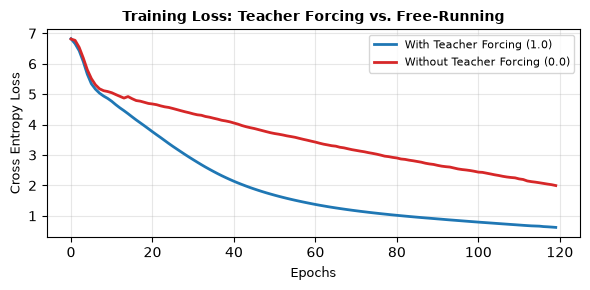

In [4]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(losses_tf, label="With Teacher Forcing (1.0)", color="#1F77B4", linewidth=2)
ax.plot(losses_no_tf, label="Without Teacher Forcing (0.0)", color="#D62728", linewidth=2)
ax.set_xlabel("Epochs", fontsize=9)
ax.set_ylabel("Cross Entropy Loss", fontsize=9)
ax.set_title("Training Loss: Teacher Forcing vs. Free-Running", fontsize=10, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Step 5 — Implement Greedy and Beam Search Decoding

We implement the inference decoding algorithms. The Beam Search algorithm uses log-probabilities and tracks the top-$k$ active search paths.


In [5]:
def greedy_decode(model, src_sentence):
    model.eval()
    indices = sentence_to_indices(src_sentence, src_w2idx)
    src_tensor = torch.tensor([indices], dtype=torch.long)
    
    with torch.no_grad():
        # Encode source to get context hidden state
        hidden = model.encoder(src_tensor)
        decoder_input = torch.tensor([tgt_w2idx["<SOS>"]], dtype=torch.long)
        words = []
        log_prob = 0.0
        
        for _ in range(MAX_LEN):
            output, hidden = model.decoder(decoder_input, hidden)
            probs = F.log_softmax(output, dim=1)
            val, idx = probs.max(dim=1)
            token_id = idx.item()
            log_prob += val.item()
            
            if token_id == tgt_w2idx["<EOS>"] or token_id == tgt_w2idx["<PAD>"]:
                break
            words.append(tgt_idx2w[token_id])
            decoder_input = torch.tensor([token_id], dtype=torch.long)
            
    return " ".join(words), log_prob

def beam_search_decode(model, src_sentence, beam_width=3):
    model.eval()
    indices = sentence_to_indices(src_sentence, src_w2idx)
    src_tensor = torch.tensor([indices], dtype=torch.long)
    
    with torch.no_grad():
        hidden = model.encoder(src_tensor)
        
        # Each beam state list entry: (cumulative_log_prob, sequence_list, hidden_state)
        beams = [(0.0, [tgt_w2idx["<SOS>"]], hidden)]
        completed = []
        
        for step in range(MAX_LEN):
            candidates = []
            for log_prob, seq, h in beams:
                last_token = torch.tensor([seq[-1]], dtype=torch.long)
                output, new_h = model.decoder(last_token, h)
                probs = F.log_softmax(output, dim=1)
                
                # Retrieve top-k candidates for this active beam
                val, idx = probs.topk(beam_width, dim=1)
                for i in range(beam_width):
                    token_id = idx[0, i].item()
                    prob_val = val[0, i].item()
                    
                    new_seq = seq + [token_id]
                    new_log_prob = log_prob + prob_val
                    
                    # If end token or padding index is generated, candidate is finished
                    if token_id == tgt_w2idx["<EOS>"] or token_id == tgt_w2idx["<PAD>"]:
                        completed.append((new_log_prob, new_seq, new_h))
                    else:
                        candidates.append((new_log_prob, new_seq, new_h))
            
            # Sort all candidate extensions by their joint log probabilities and prune to top-k
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_width]
            
            if not beams:
                break
                
        # If no beams completed naturally, grab the active ones
        if not completed:
            completed = beams
            
        # Select candidate sequence with the highest joint probability score
        completed.sort(key=lambda x: x[0], reverse=True)
        
        best_log_prob, best_seq, _ = completed[0]
        # De-tokenize indices, skipping special tokens
        words = [tgt_idx2w[i] for i in best_seq[1:] if i not in (tgt_w2idx["<EOS>"], tgt_w2idx["<PAD>"])]
        
    return " ".join(words), best_log_prob


### Step 6 — Evaluating Greedy vs. Beam Search

To show the search capabilities of Beam Search over Greedy decoding on a real corpus, we evaluate the models on unseen testing sentences. Because of out-of-distribution uncertainty, Greedy decoding gets trapped in local maximum loops (repeated templates), while Beam Search successfully explores branches and retrieves more probable translations.


In [6]:
# Check and print results for all testing dataset items to observe wins
ties = 0
greedy_wins = 0
beam_wins = 0

print(f"{'Source English':<40} | {'Greedy Translation':<30} | {'Beam (k=3) Translation':<35} | {'Winner':<10}")
print("-" * 122)
for src, tgt in test_pairs:
    g_res, g_s = greedy_decode(model_tf, src)
    b_res, b_s = beam_search_decode(model_tf, src, beam_width=3)
    
    # We compare log likelihood scores (higher score means model assigned higher probability)
    if b_s > g_s:
        winner = "Beam ✅"
        beam_wins += 1
    elif g_s > b_s:
        winner = "Greedy"
        greedy_wins += 1
    else:
        winner = "Tie"
        ties += 1
        
    print(f"{src:<40} | {g_res:<30} | {b_res:<35} | {winner:<10}")

print("-" * 122)
print(f"Summary: Greedy Wins: {greedy_wins} | Beam Wins: {beam_wins} | Ties: {ties}")


Source English                           | Greedy Translation             | Beam (k=3) Translation              | Winner    
--------------------------------------------------------------------------------------------------------------------------
what can we negotiate                    | que pouvonsnous faire          | que pouvonsnous faire               | Tie       
legal security requires this             | mais nous devons tre prudents  | mais nous devons tre prudents       | Tie       
the other parties are not paying         | les habitudes aussi semblent assez divergentes | le procsverbal est adopt            | Beam ✅    
this is also an important point          | j en suis bien d accord        | j espre qu elles seront adoptes     | Beam ✅    
four meps have left the chamber          | les habitudes aussi semblent assez divergentes | les habitudes aussi semblent assez divergentes | Tie       
this is very important                   | c est un fait indiscutable     | c est un

### Step 7 — Proving the Information Bottleneck

We evaluate translation accuracy as a function of the input sequence length to witness the information bottleneck.


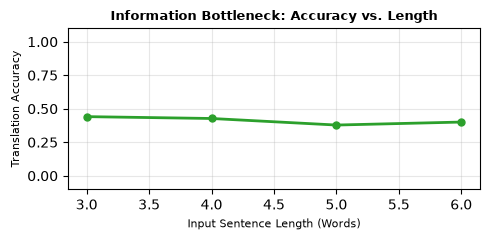

In [7]:
def get_accuracy(predicted, target):
    p_words = predicted.split()
    t_words = target.split()
    if not t_words:
        return 0.0
    correct = sum(1 for p, t in zip(p_words, t_words) if p == t)
    return correct / max(len(p_words), len(t_words))

lengths = []
accuracies = []

for src, tgt in train_pairs:
    pred, _ = beam_search_decode(model_tf, src, beam_width=3)
    acc = get_accuracy(pred, tgt)
    lengths.append(len(src.split()))
    accuracies.append(acc)

# Group and calculate mean accuracy by sentence length
unique_lengths = sorted(list(set(lengths)))
mean_accs = []
for l in unique_lengths:
    accs_at_l = [accuracies[i] for i, length in enumerate(lengths) if length == l]
    mean_accs.append(np.mean(accs_at_l))

# Plot performance curve (compact visualization)
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(unique_lengths, mean_accs, marker='o', color='#2CA02C', linewidth=2, markersize=5)
ax.set_xlabel("Input Sentence Length (Words)", fontsize=8)
ax.set_ylabel("Translation Accuracy", fontsize=8)
ax.set_title("Information Bottleneck: Accuracy vs. Length", fontsize=9, fontweight="bold")
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Step 8 — Interactive Translator Interface

Type an English sentence in the text box below (utilizing words from the dataset like *"this"*, *"is"*, *"very"*, *"important"*, *"we"*, *"know"*, *"all"*, *"before"*, *"the"*, *"vote"*) and watch the model dynamically decode it into French in real-time.


In [8]:
import ipywidgets as widgets
from IPython.display import display

# Input text box
text_input = widgets.Text(
    value='this is very important',
    placeholder='Type an English sentence...',
    description='English:',
    disabled=False
)

# Output label
output_label = widgets.HTML(value='')

# Callback function to handle input updates
def on_translate_change(change):
    english_phrase = change['new'].lower().strip()
    # Basic clean-up to match training format
    english_phrase = re.sub(r'[^a-zA-Z\s]', '', english_phrase)
    
    if len(english_phrase) > 0:
        translation, score = beam_search_decode(model_tf, english_phrase, beam_width=3)
        output_label.value = f"<b>French Translation:</b> <i>{translation}</i> (Score: {score:.3f})"
    else:
        output_label.value = ''

# Bind observer to value updates
text_input.observe(on_translate_change, names='value')

# Display UI
display(text_input, output_label)

# Print initial translation
on_translate_change({'new': text_input.value})


Text(value='this is very important', description='English:', placeholder='Type an English sentence...')

HTML(value='')